In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.registration import phase_cross_correlation

In [2]:
### load the data
files = sorted(Path('Data').glob('*.fits'))
data = np.array([fits.getdata(file).astype(float) for file in files])

print(f'Found {len(data)} files')

Found 142 files


In [3]:
### Let's only use the first 100 files since 142 is a lot for training
data = data[:100]

In [4]:
def drift_corr(im1, im2):
    """
    Find (dy, dx) shift from im1 to im2.
    Detects the 3 strongest Gaussian peaks in im1, builds a soft
    weight mask around them, and runs phase cross-correlation on
    the weighted images.
    """
    def make_weight_mask(img, n_peaks=1, peak_sigma=20):
        # smooth to find broad intensity peaks, not noise spikes
        smoothed = gaussian_filter(img.astype(np.float32), sigma=3)

        # find top n local maxima, spaced at least max_shift apart
        peaks = peak_local_max(
            smoothed,
            num_peaks=n_peaks,
        )

        # build mask: sum of Gaussians centered on each peak
        H, W = img.shape
        yy, xx = np.mgrid[0:H, 0:W]
        mask = np.zeros((H, W), dtype=np.float32)
        for py, px in peaks:
            mask += np.exp(-((yy - py)**2 + (xx - px)**2) / (2 * peak_sigma**2))

        # normalize to [0, 1]
        mask /= mask.max() + 1e-8
        return mask

    # build weight mask from im1's features
    mask = make_weight_mask(im1)

    # apply mask to both images before correlation
    w1 = im1.astype(np.float32) * mask
    w2 = im2.astype(np.float32) * mask

    # phase cross-correlation, restricted to max_shift
    shift, _, _ = phase_cross_correlation(
        w1, w2,
        upsample_factor=10,         # sub-pixel precision
        normalization='phase',
    )

    dy, dx = shift

    return dy, dx

In [5]:
### find shift between two consecutive images
shifts = []
for i in range(len(data) - 1):
    shift = drift_corr(data[i], data[i + 1])
    shifts.append(shift)

In [6]:
### slice the images to the common area after applying the cumulative shifts

# compute cumulative offsets from the pairwise shifts
offsets = [(0, 0)]                 # image 0 is the reference
for dy, dx in shifts:
    prev_y, prev_x = offsets[-1]
    offsets.append((prev_y + dy, prev_x + dx))

H, W = data[0].shape[:2]

# find the overlapping crop window
off_y = np.array([o[0] for o in offsets])
off_x = np.array([o[1] for o in offsets])

y_top   = int(off_y.max())         # latest top edge
y_bot   = int((off_y + H).min())   # earliest bottom edge
x_left  = int(off_x.max())         # latest left edge
x_right = int((off_x + W).min())   # earliest right edge

# crop each image using its own offset
cropped = []

for img, (dy, dx) in zip(data, offsets):
    y_start = int(y_top - dy)
    y_end   = y_start + (y_bot - y_top)
    x_start = int(x_left - dx)          
    x_end   = x_start + (x_right - x_left)

    cropped.append(img[y_start:y_end, x_start:x_end])

In [7]:
import numpy as np
import SimpleITK as sitk


def register_stack(
    stack: np.ndarray,
    reference: np.ndarray | None = None,
    num_iterations: int = 100,
    std_deviations: float = 1.0,
    verbose: bool = False,
) -> tuple[np.ndarray, list[sitk.DisplacementFieldTransform]]:
    """
    Apply Demons registration to a stack of N rigidly-shifted images. https://simpleitk.readthedocs.io/en/master/link_DemonsRegistration1_docs.html
    """
    N = stack.shape[0]

    ref_array = reference.astype(np.float32)

    fixed = sitk.GetImageFromArray(ref_array)

    registered_stack = np.empty_like(stack, dtype=np.float32)
    transforms = []

    for i in tqdm(range(N)):
        if verbose:
            print(f"\n── Frame {i+1}/{N} ──")

        frame = stack[i].astype(np.float32)
        moving = sitk.GetImageFromArray(frame)

        # Histogram matching
        matcher = sitk.HistogramMatchingImageFilter()
        matcher.SetNumberOfHistogramLevels(1024)
        matcher.SetNumberOfMatchPoints(7)
        matcher.ThresholdAtMeanIntensityOn()
        moving_matched = matcher.Execute(moving, fixed)

        # Demons
        demons = sitk.DemonsRegistrationFilter()
        demons.SetNumberOfIterations(num_iterations)
        demons.SetStandardDeviations(std_deviations)

        if verbose:
            demons.AddCommand(
                sitk.sitkIterationEvent,
                lambda: print(
                    f"  {demons.GetElapsedIterations():3} | metric: {demons.GetMetric():10.5f}",
                    end="\r",
                ),
            )

        displacement_field = demons.Execute(fixed, moving_matched)

        if verbose:
            print(
                f"  Done — iterations: {demons.GetElapsedIterations()}, "
                f"RMS: {demons.GetRMSChange():.5f}"
            )

        # Resample
        transform = sitk.DisplacementFieldTransform(displacement_field)

        resampler = sitk.ResampleImageFilter()
        resampler.SetReferenceImage(fixed)
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetDefaultPixelValue(0)
        resampler.SetTransform(transform)

        registered_sitk = resampler.Execute(moving)  # resample original, not matched
        registered_stack[i] = sitk.GetArrayFromImage(registered_sitk)
        transforms.append(transform)

    return registered_stack, transforms

In [8]:
registered_stack, transforms = register_stack(np.array(cropped), reference=cropped[len(cropped) // 2])

100%|██████████| 100/100 [01:19<00:00,  1.26it/s]


In [10]:
# crop registered stack to be able to go through CNN of dimension 5, so must be divisible by 32
H, W = registered_stack.shape[1:]
crop_H = H - (H % 32)
crop_W = W - (W % 32)
print(f"Cropping to {crop_H}x{crop_W} to be divisible by 32 for CNN input")

# crop half of the pixels from each side
crop_top = (H - crop_H) // 2
crop_left = (W - crop_W) // 2
cropped_registered_stack = registered_stack[:, crop_top:crop_top+crop_H, crop_left:crop_left+crop_W]

Cropping to 800x800 to be divisible by 32 for CNN input


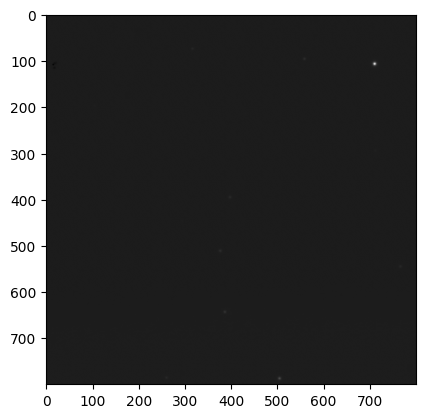

In [11]:
plt.imshow(np.mean(cropped_registered_stack, axis=0), cmap='gray');

In [12]:
np.save('LPSEB_registered.npy', cropped_registered_stack)